# 04 — Trade flow & lead-lag (P3)

**What this notebook answers**

- Aggressor balance (taker-buy vs taker-sell volume) by venue.
- Trade-size distribution (CCDF, log-log).
- Cross-venue lead-lag of trade-flow imbalance via cross-correlation.
- Cross-venue lead-lag of mid returns.

If Binance reliably leads HL by Δ ms, that's directly actionable for an MM:
widen / skew quotes on HL when Binance prints aggression.

In [1]:
from hlanalysis.analysis import duck, glob_for, load_df, set_mpl_defaults
import pandas as pd, numpy as np, matplotlib.pyplot as plt
set_mpl_defaults()

def trades_df(venue, product_type, symbol):
    g = glob_for(venue=venue, product_type=product_type, event='trade', symbol=symbol)
    df = load_df(f'''
        SELECT exchange_ts, price, size, side
        FROM read_parquet('{g}', hive_partitioning=true)
        ORDER BY exchange_ts
    ''')
    if df.empty: return df
    df['t'] = pd.to_datetime(df.exchange_ts, unit='ns', utc=True)
    df['signed_size'] = np.where(df.side=='buy', df['size'], np.where(df.side=='sell', -df['size'], 0))
    return df.set_index('t')

trades = {
    'HL perp BTC':      trades_df('hyperliquid','perp','BTC'),
    'Binance perp BTC': trades_df('binance','perp','BTCUSDT'),
    'Binance spot BTC': trades_df('binance','spot','BTCUSDT'),
}
{k: len(v) for k,v in trades.items()}

{'HL perp BTC': 428002,
 'Binance perp BTC': 2878373,
 'Binance spot BTC': 1985747}

## 1. Aggressor imbalance per minute

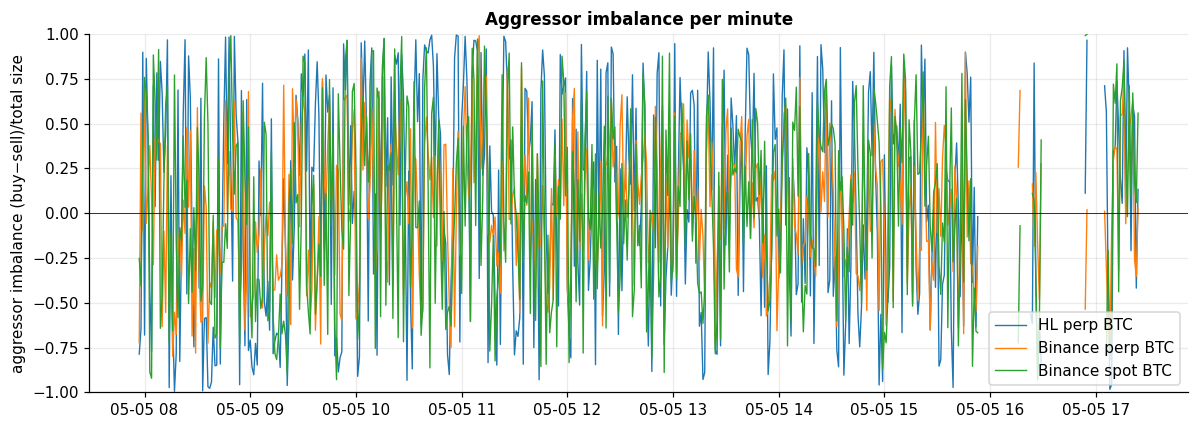

In [2]:
fig, ax = plt.subplots(figsize=(11,4))
for k, df in trades.items():
    if df.empty: continue
    m = df['signed_size'].resample('1min').sum() / df['size'].resample('1min').sum()
    ax.plot(m, label=k, lw=0.9)
ax.axhline(0, color='k', lw=0.5); ax.set_ylim(-1,1)
ax.set_ylabel('aggressor imbalance (buy−sell)/total size')
ax.set_title('Aggressor imbalance per minute'); ax.legend()
plt.tight_layout(); plt.show()

## 2. Trade-size CCDF (log-log)

Power-law-ish ⇒ heavy tail ⇒ giant prints drive markouts. Slope is informative.

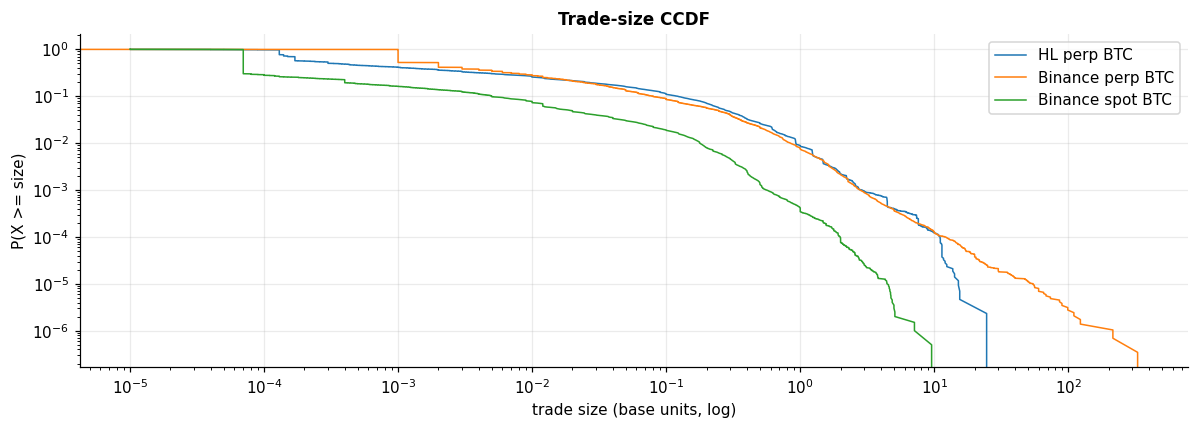

In [3]:
fig, ax = plt.subplots(figsize=(11,4))
for k, df in trades.items():
    if df.empty: continue
    s = np.sort(df['size'].values)
    ccdf = 1 - np.arange(1, len(s)+1)/len(s)
    ax.plot(s, ccdf, label=k, lw=1.0)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('trade size (base units, log)'); ax.set_ylabel('P(X >= size)')
ax.set_title('Trade-size CCDF'); ax.legend()
plt.tight_layout(); plt.show()

## 3. Cross-venue lead-lag — flow imbalance

Resample signed flow at 100 ms; compute cross-correlation HL vs Binance perp at
±5 s lags. Peak position tells you who leads.

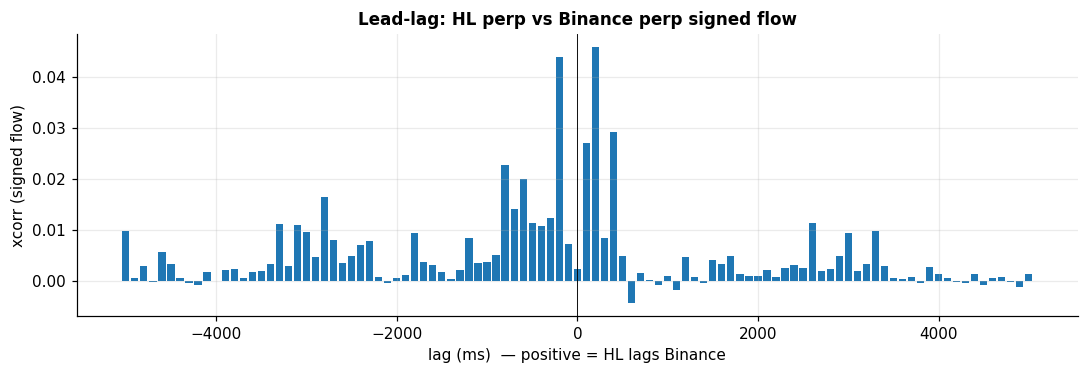

peak |xcorr| at lag = 200 ms (positive ⇒ HL lags Binance)


In [4]:
def flow_grid(df, freq='100ms'):
    if df.empty: return pd.Series(dtype=float)
    return df['signed_size'].resample(freq).sum().fillna(0)

a = flow_grid(trades['HL perp BTC'])
b = flow_grid(trades['Binance perp BTC'])
common = a.index.intersection(b.index)
a = a.loc[common]; b = b.loc[common]

def xcorr(a, b, max_lag=50):
    a = (a - a.mean())/(a.std() or 1)
    b = (b - b.mean())/(b.std() or 1)
    n = len(a); lags = np.arange(-max_lag, max_lag+1)
    out = []
    for L in lags:
        if L < 0:   c = np.dot(a[-L:].values, b[:n+L].values)/(n-abs(L))
        elif L > 0: c = np.dot(a[:n-L].values, b[L:].values)/(n-L)
        else:       c = np.dot(a.values, b.values)/n
        out.append(c)
    return lags, np.array(out)

lags, cc = xcorr(a, b, max_lag=50)  # ±5s at 100ms grid
fig, ax = plt.subplots(figsize=(10,3.5))
ax.bar(lags*100, cc, width=80)
ax.axvline(0, color='k', lw=0.6)
ax.set_xlabel('lag (ms)  — positive = HL lags Binance')
ax.set_ylabel('xcorr (signed flow)')
ax.set_title('Lead-lag: HL perp vs Binance perp signed flow')
plt.tight_layout(); plt.show()
peak = lags[int(np.argmax(np.abs(cc)))]*100
print(f'peak |xcorr| at lag = {peak} ms (positive ⇒ HL lags Binance)')

## 4. Cross-venue lead-lag — mid returns

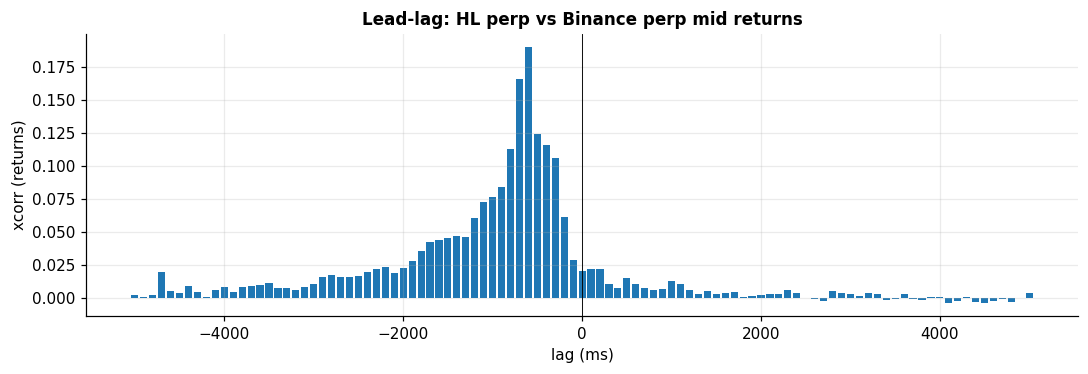

peak |xcorr| at lag = -600 ms


In [5]:
from hlanalysis.analysis import glob_for
def mid_grid(venue, product_type, symbol, freq='100ms'):
    g = glob_for(venue=venue, product_type=product_type, event='bbo', symbol=symbol)
    df = load_df(f'''
        SELECT exchange_ts, (bid_px+ask_px)/2.0 AS mid
        FROM read_parquet('{g}', hive_partitioning=true)
        WHERE bid_px>0 AND ask_px>0 ORDER BY exchange_ts
    ''')
    if df.empty: return pd.Series(dtype=float)
    s = df.set_index(pd.to_datetime(df.exchange_ts, unit='ns', utc=True))['mid']
    s = s.resample(freq).last().ffill()
    return s.pct_change()

ra = mid_grid('hyperliquid','perp','BTC')
rb = mid_grid('binance','perp','BTCUSDT')
common = ra.index.intersection(rb.index)
ra = ra.loc[common].fillna(0); rb = rb.loc[common].fillna(0)
lags, cc = xcorr(ra, rb, max_lag=50)
fig, ax = plt.subplots(figsize=(10,3.5))
ax.bar(lags*100, cc, width=80); ax.axvline(0, color='k', lw=0.6)
ax.set_xlabel('lag (ms)'); ax.set_ylabel('xcorr (returns)')
ax.set_title('Lead-lag: HL perp vs Binance perp mid returns')
plt.tight_layout(); plt.show()
peak = lags[int(np.argmax(np.abs(cc)))]*100
print(f'peak |xcorr| at lag = {peak} ms')